<IPython.core.display.Javascript object>


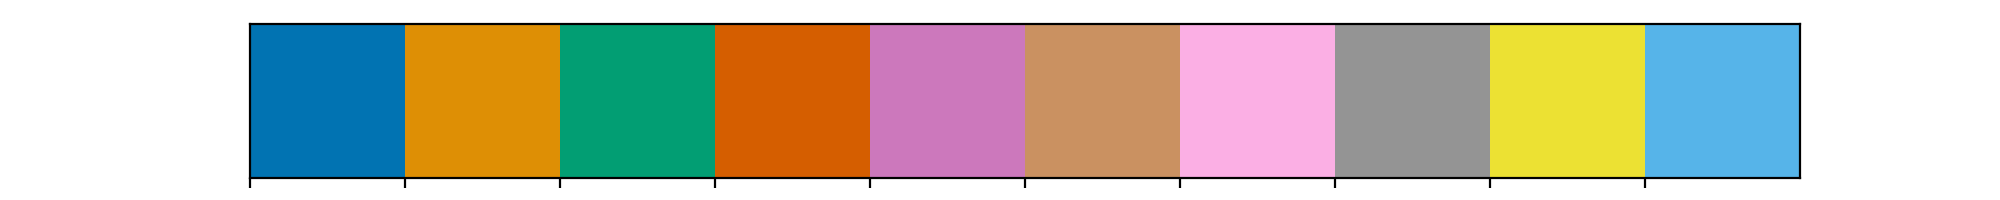

In [1]:
from whampy import SkySurvey
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

import astropy.units as u
import astropy.constants as c
from astropy.coordinates import Angle

from astropy.coordinates import SkyCoord

from dustmaps.bayestar import BayestarQuery
from dustmaps.decaps import DECaPSQueryLite, DECaPSQuery
from astropy.table import hstack, vstack, dstack
import os
from astropy_healpix import HEALPix

pal = sns.color_palette("colorblind")
%matplotlib notebook

sns.palplot(pal)
from extinction import fm07 as extinction_law

In [2]:
extinction_law?

In [4]:
wave_ha = np.array([6562.8])
wave_hb = np.array([4861.3])
A_V_to_A_ha = extinction_law(wave_ha, 1.)
A_V_to_A_hb = extinction_law(wave_hb, 1.)
print(A_V_to_A_ha)
print(A_V_to_A_hb)

[0.77112855]
[1.17664704]


In [64]:
hp = HEALPix(nside=4096, order='nested', frame = "galactic")

In [63]:
8192/2

4096.0

In [3]:
ha = SkySurvey()

In [4]:
coords = ha.get_SkyCoord()

In [62]:
hp.cone_se

<Angle 359.99997 deg>

In [78]:
from functools import partial
cone_search = partial(hp.cone_search_skycoord, radius = 0.5*u.deg)
test_coords = [*map(cone_search, coords[:10])]

In [87]:
from multiprocessing import Pool
with Pool() as p:
    test_coords_2 = p.map(cone_search, coords[:10])

In [90]:
test_coords

[array([173287693, 173287704, 173287706, ..., 173112600, 173112595,
        173112596]),
 array([173283454, 173283455, 173283541, ..., 173280773, 173280775,
        173280780]),
 array([195569934, 195569935, 195569957, ..., 173282758, 173282759,
        173282770]),
 array([195565777, 195565780, 195565782, ..., 195572285, 195572286,
        195572369]),
 array([195225832, 195225833, 195225835, ..., 195576481, 195576480,
        195565559]),
 array([195573023, 195573066, 195573088, ..., 195575560, 195575389,
        195575390]),
 array([195571704, 195571705, 195571707, ..., 195595721, 195595722,
        195595701]),
 array([195594883, 195594886, 195594892, ..., 195592827, 195592912,
        195592914]),
 array([173296262, 173296263, 173296269, ..., 173284998, 173284997,
        173284922]),
 array([173292085, 173292128, 173292130, ..., 173288997, 173288998,
        173289001])]

In [65]:
hp_inds_in_pointing = hp.cone_search_lonlat(-20*u.deg, 0.*u.deg, 0.5*u.deg)

In [66]:
hp_coords_in_pointing = hp.healpix_to_skycoord(hp_inds_in_pointing)

In [67]:
coords_icrs = coords.transform_to("icrs")

In [68]:
hp_coords_gal_in_pointing = hp_coords_in_pointing.transform_to("galactic")

<IPython.core.display.Javascript object>


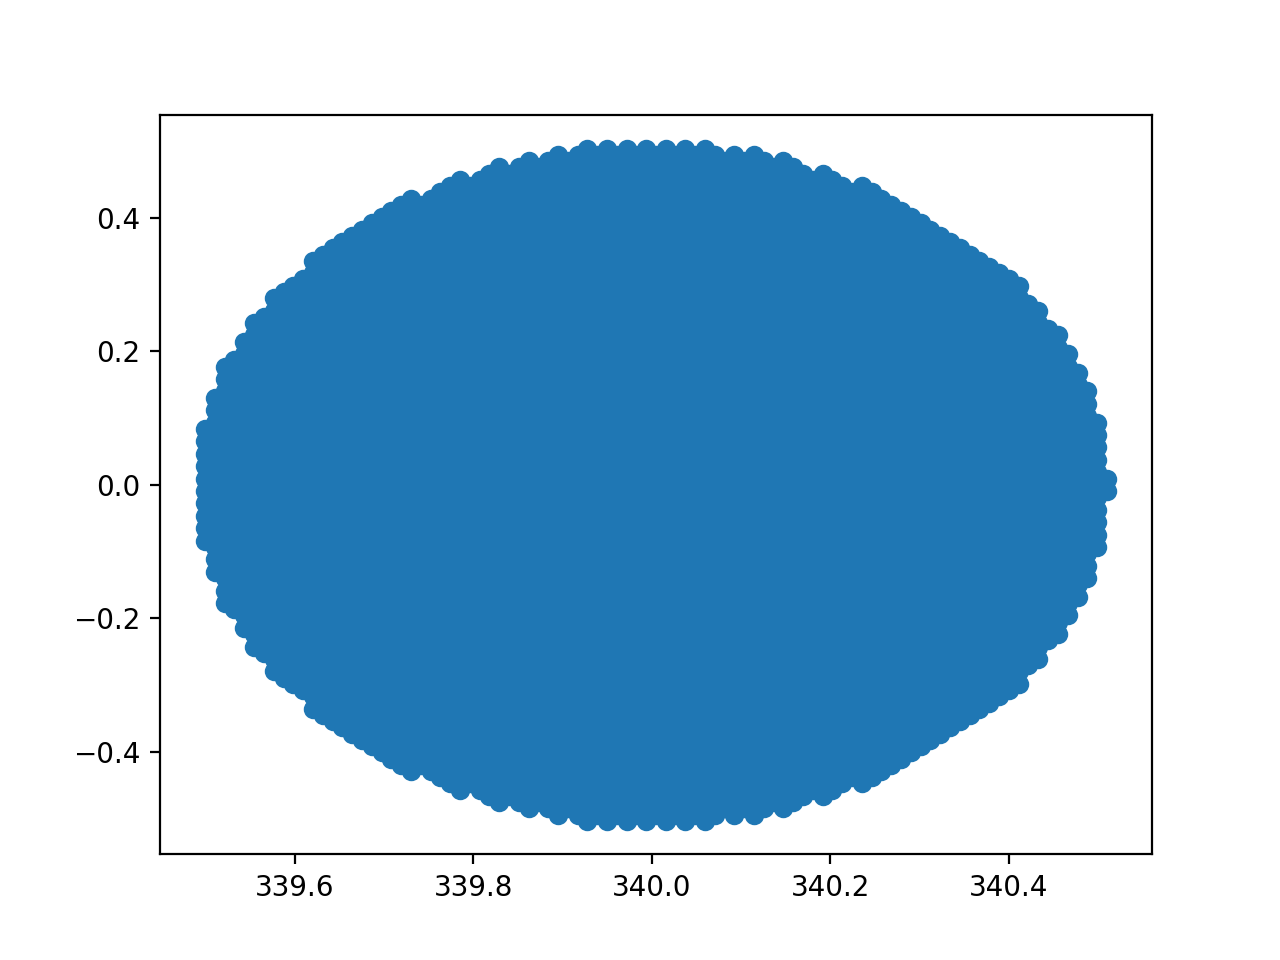

In [69]:
fig,ax = plt.subplots()
ax.scatter(hp_coords_gal_in_pointing.l, hp_coords_gal_in_pointing.b)
# ax.scatter(coords.l[0], coords.b[0])

In [10]:
decaps = DECaPSQuery(mean_only=True)

You are about to load 7 GB into RAM. If you are not performing intensive queries, consider using the DECaPSQueryLite class.
Loading pixel info...
Allocating memory for mean map...
Loading mean map in chunks...


Mean Map Loading: 100%|██████████| 515/515 [01:26<00:00,  5.93it/s]


Data loading complete!


In [113]:
def get_hp_coords(coord, deredden_method = "bayestar"):
    if deredden_method == "bayestar":
        inds_in_coord = hp.cone_search_skycoord(coord, 0.5*u.deg)
        return hp.healpix_to_skycoord(inds_in_coord)
    else:
        inds_in_coord = hp_decaps.cone_search_skyCoord(coord, 0.5*u.deg)
        return hp_decaps.healpix_to_skycoord(inds_in_coord)
    
tt = [*map(get_hp_coords,coords[:3])]

In [122]:
[*map(np.isnan, np.vstack([[1,np.nan,3], [1,2,3]]))]

[array([False,  True, False]), array([False, False, False])]

In [152]:
inten = np.arange(200).reshape(20,10)
Av = np.arange(500)
inten_dered = inten[:,:,None] * Av

In [153]:
inten_dered.shape

(20, 10, 500)

In [147]:
isnan = partial(np.isnan, axis = 1)
np.all(np.isnan(np.vstack([[np.nan,np.nan,np.nan], [1,2,3]])), axis = 1)

array([ True, False])

<IPython.core.display.Javascript object>


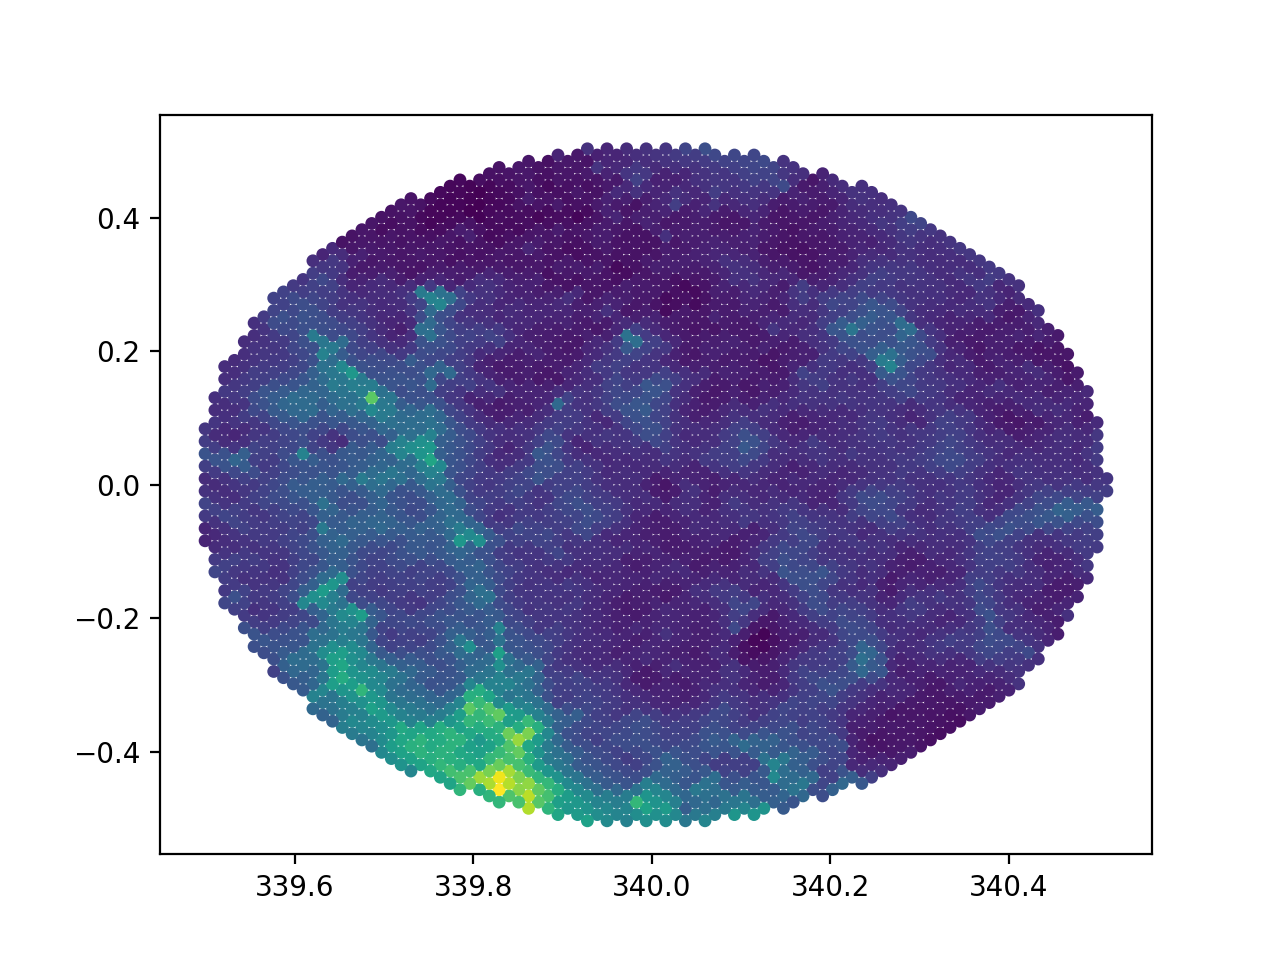

In [75]:
fig,ax = plt.subplots()
ax.scatter(hp_coords_gal_in_pointing.l, hp_coords_gal_in_pointing.b, c = evb[:,60], s = 13)


In [77]:
pool = "asdfsd"
if pool is None:
    print("yes")

In [15]:
decaps.query?

In [155]:
c1 = SkyCoord(l = np.arange(80)*u.deg, b = np.arange(80)*u.deg, frame = "galactic")
c2 = SkyCoord(l = np.arange(80)*u.deg, b = np.arange(80)*u.deg, frame = "galactic")

In [183]:
c3 =dstack([c1, c2])

In [187]:
c3["col0"].shape

(80, 2)

In [2]:
np.percentile?

In [3]:
a = [1,2,3]
b = [True, True, False]
def apply(a_b):
    a,b = a_b
    print (a, b)
[*map(apply, zip(a,b))]

1 True
2 True
3 False


[None, None, None]